# Create the Figure 4 and Figure 5: Per-sample agreement between human annotations and GPT or Llama.

/var/folders/5w/511b227d2z53cxgmdw8rgp400000gp/T/ipykernel_84624/3062927310.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  llm_output_numnot1['all_scores'] = llm_output_numnot1['all_scores'].apply(lambda x: eval(x))
/var/folders/5w/511b227d2z53cxgmdw8rgp400000gp/T/ipykernel_84624/3062927310.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  llm_output_numnot1['output_scores'] = llm_output_numnot1['output_scores'].apply(lambda x: eval(x))
/var/folders/5w/511b227d2z53cxgmdw8rgp400000gp/T/ipykernel_846

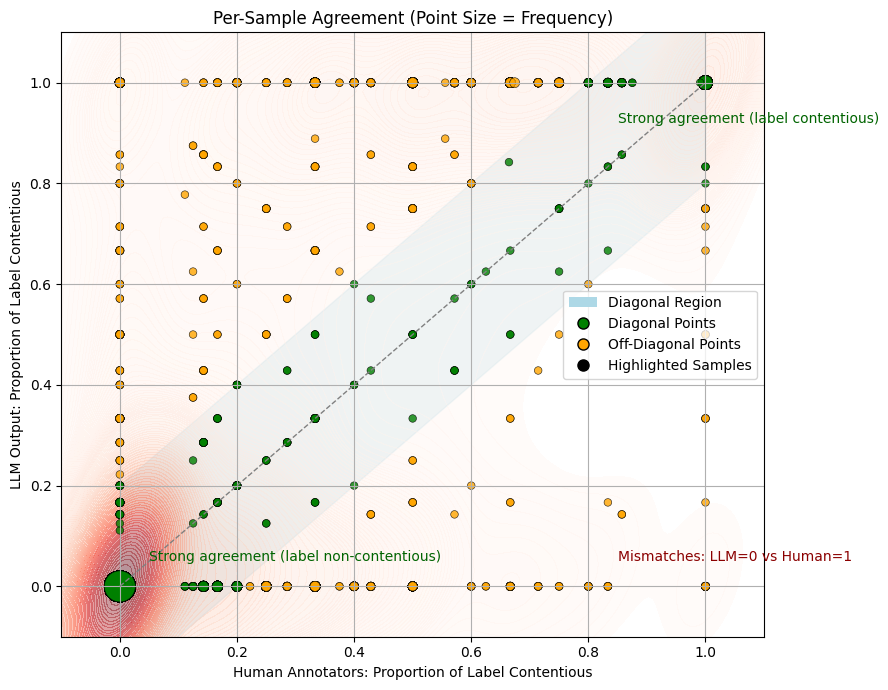

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib as mpl

# Load and preprocess the data
def load_and_preprocess_data(file_path):
    llm_output = pd.read_csv(file_path)
    
    # Remove 'point_count' column if it exists
    if 'point_count' in llm_output.columns:
        llm_output.drop(columns=['point_count'], inplace=True)
    
    # Filter to include only samples with more than one annotator
    llm_output['num_annotator'] = llm_output['output_scores'].apply(lambda x: len(eval(x)))
    llm_output_numnot1 = llm_output[llm_output['num_annotator'] > 1]
    
    # Convert string representations of lists back to actual lists
    llm_output_numnot1['annotations'] = llm_output_numnot1['annotations'].apply(lambda x: eval(x))
    llm_output_numnot1['output_scores'] = llm_output_numnot1['output_scores'].apply(lambda x: eval(x))
    llm_output_numnot1['percentage_1_human'] = llm_output_numnot1['annotations'].apply(lambda x: x.count(1)/len(x))
    llm_output_numnot1['percentage_1_llm'] = llm_output_numnot1['output_scores'].apply(lambda x: x.count(1)/len(x))
    
    return llm_output_numnot1

# Calculate density and define diagonal regions
def calculate_density_and_regions(data):
    # Round the percentages to 2 decimal places for grouping
    data['x_round'] = data['percentage_1_human'].round(2)
    data['y_round'] = data['percentage_1_llm'].round(2)
    density_df = data.groupby(['x_round', 'y_round']).size().reset_index(name='point_count')
    data = data.merge(density_df, on=['x_round', 'y_round'], how='left')
    
    # Define diagonal region
    data['in_diagonal_region'] = (
        np.abs(data['percentage_1_human'] - data['percentage_1_llm']) <= 0.2
    )
    
    # Create a new column for region labels
    data['region_label'] = data['in_diagonal_region'].map({
        True: 'Diagonal Region',
        False: 'Off Diagonal'
    })
    
    return data

# Create a scatter plot with density contours.
def plot_scatter_with_density(data, output_file):
    plt.figure(figsize=(9, 7))
    
    x = np.linspace(0, 1, 100)
    plt.fill_between(x, x-0.2, x+0.2, color='lightblue', alpha=0.3, label='Near Perfect Alignment')
    
    sns.kdeplot(
        data=data,
        x='percentage_1_human',
        y='percentage_1_llm',
        cmap='Reds',
        fill=True,
        thresh=0.02,
        levels=100,
        alpha=0.4
    )
    
    sns.scatterplot(
        data=data,
        x='percentage_1_human',
        y='percentage_1_llm',
        hue='region_label',
        palette={'Diagonal Region': 'green', 'Off Diagonal': 'orange'},
        size='point_count',
        sizes=(30, 500),
        alpha=0.8,
        edgecolor='black',
        legend=False
    )
    
    plt.text(0.05, 0.05, 'Strong agreement (label non-contentious)', fontsize=10, color='darkgreen')
    plt.text(0.85, 0.92, 'Strong agreement (label contentious)', fontsize=10, color='darkgreen')
    plt.text(0.85, 0.05, 'Mismatches: LLM=0 vs Human=1', fontsize=10, color='darkred')
    
    plt.plot([0, 1], [0, 1], 'gray', linestyle='--', linewidth=1)
    plt.xlabel('Human Annotators: Proportion of Label Contentious')
    plt.ylabel('LLM Output: Proportion of Label Contentious')
    plt.title('Per-Sample Agreement (Point Size = Frequency)')
    plt.xlim(-0.1, 1.1)
    plt.ylim(-0.1, 1.1)
    
    legend_elements = [
        Patch(facecolor='lightblue', edgecolor='none', label='Diagonal Region'),
        Line2D([0], [0], marker='o', color='green', label='Diagonal Points',
               markerfacecolor='green', markeredgecolor='black', markersize=8, linestyle='None'),
        Line2D([0], [0], marker='o', color='orange', label='Off-Diagonal Points',
               markerfacecolor='orange', markeredgecolor='black', markersize=8, linestyle='None'),
        Line2D([0], [0], marker='o', color='black', label='Highlighted Samples',
               markerfacecolor='black', markeredgecolor='black', markersize=8, linestyle='None')
    ]
    
    plt.legend(handles=legend_elements, title='')
    plt.grid(True)
    plt.tight_layout()
    mpl.rcParams['pdf.fonttype'] = 42
    plt.savefig(output_file, format="pdf", bbox_inches="tight")
    plt.show()

# file paths: check the file paths and uncomment the one you want to use
file_path = './gpt-4o_temperature1_ori-en-CandR.csv' # gpt-4o
# file_path = './llama-3-70b_temperature1_ori-en-CandR.csv' # llama-3-70b

output_file = "./scatter_gpt.pdf" 
# output_file = "./scatter_llama.pdf"

llm_output_numnot1 = load_and_preprocess_data(file_path)
llm_output_numnot1 = calculate_density_and_regions(llm_output_numnot1)
plot_scatter_with_density(llm_output_numnot1, output_file)

# Randomly select 50 samples from 7 areas from the scatterplot due to the difference among human and LLM label.

In [3]:
# Select samples for analysis
import pandas as pd
import numpy as np

# Choose lines where the column 'num_annotator' is more than 1
# Convert values of the all_scores column and output_scores column from strings to lists and calculate the percentage of 1 in the lists
llm_output = pd.read_csv(file_path)
llm_output['num_annotator'] = llm_output['output_scores'].apply(lambda x: len(eval(x)))
llm_output_numnot1 = llm_output[llm_output['num_annotator'] > 1]
llm_output_numnot1['annotations'] = llm_output_numnot1['annotations'].apply(lambda x: eval(x))
llm_output_numnot1['output_scores'] = llm_output_numnot1['output_scores'].apply(lambda x: eval(x))
llm_output_numnot1['percentage_1_human'] = llm_output_numnot1['annotations'].apply(lambda x: x.count(1)/len(x))
llm_output_numnot1['percentage_1_llm'] = llm_output_numnot1['output_scores'].apply(lambda x: x.count(1)/len(x))
llm_output_numnot1['distance_to_diagonal_abs'] = np.abs(llm_output_numnot1['percentage_1_human'] - llm_output_numnot1['percentage_1_llm'])
llm_output_numnot1['distance_to_diagonal'] = llm_output_numnot1['percentage_1_human'] - llm_output_numnot1['percentage_1_llm']


# 7 types of samples to select:
# 1. Extreme disagreement (one of LLM or human must be exactly 0 or 1)
extreme_points = llm_output_numnot1[
    (llm_output_numnot1['percentage_1_human'].isin([0, 1])) |
    (llm_output_numnot1['percentage_1_llm'].isin([0, 1]))
]

# From extreme points, select those where disagreement is strong
extreme_disagree_1 = extreme_points[
    ((extreme_points['percentage_1_human'] ==1) & (extreme_points['percentage_1_llm'] ==0))
]
# show the number of extreme_disagree_2
print("Extreme agreement 1:", extreme_disagree_1.shape[0])
sample_extreme_disagree_1 = extreme_disagree_1.sample(n=min(5, len(extreme_disagree_1)), random_state=42)
# show the number of samples
print("Sampled extreme disagreement 1:", sample_extreme_disagree_1.shape[0])

extreme_disagree_2 = extreme_points[
    ((extreme_points['percentage_1_human'] ==0) & (extreme_points['percentage_1_llm'] ==1))
]
sample_extreme_disagree_2 = extreme_disagree_2.sample(n=min(5, len(extreme_disagree_2)), random_state=42)
# show the number of samples
print("Sampled extreme disagreement 2:", sample_extreme_disagree_2.shape[0])


# 2. Extreme agreement (human == llm == 0) or (human == llm == 1)
extreme_agree_1 = extreme_points[
    ((extreme_points['percentage_1_human'] ==0) & (extreme_points['percentage_1_llm'] ==0))
]
# show the number of extreme_disagree_2
print("Extreme agreement 1:", extreme_agree_1.shape[0])
sample_extreme_agree_1 = extreme_agree_1.sample(n=min(5, len(extreme_agree_1)), random_state=42)
# show the number of samples
print("Sampled extreme agreement 1:", sample_extreme_agree_1.shape[0])

extreme_agree_2 = extreme_points[
    ((extreme_points['percentage_1_human'] ==1) & (extreme_points['percentage_1_llm'] ==1))
]
sample_extreme_agree_2 = extreme_agree_2.sample(n=min(5, len(extreme_agree_2)), random_state=42)
# show the number of samples
print("Sampled extreme agreement 2:", sample_extreme_agree_2.shape[0])


# 3. Along the diagonal (x approximately equal to y, but NOT exactly 0/0 or 1/1)
near_diagonal = llm_output_numnot1[
    (llm_output_numnot1['distance_to_diagonal_abs'] <= 0.2) &
    (~llm_output_numnot1.index.isin(extreme_points.index))  # Exclude extreme points
]

sample_along_diagonal = near_diagonal.sample(n=min(10, len(near_diagonal)), random_state=42)
# show the number of samples
print("Sampled near diagonal:", sample_along_diagonal.shape[0])

# 4. Around two disagreement zones (everything else: not extreme, not near diagonal) split into two zones
# Zone 1: Human > LLM
candidates_1 = llm_output_numnot1[
    (~llm_output_numnot1.index.isin(extreme_points.index)) &
    (llm_output_numnot1['percentage_1_human'] - llm_output_numnot1['percentage_1_llm'] > 0.2)
]
sample_around_disagree_1 = candidates_1.sample(n=min(10, len(candidates_1)), random_state=42)
# show the number of samples
print("Sampled candidate1:", sample_around_disagree_1.shape[0])
# Zone 2: Human < LLM
candidates_2 = llm_output_numnot1[
    (~llm_output_numnot1.index.isin(extreme_points.index)) &
    (llm_output_numnot1['percentage_1_human'] - llm_output_numnot1['percentage_1_llm'] < -0.2)
]
sample_around_disagree_2 = candidates_2.sample(n=min(10, len(candidates_2)), random_state=42)
# show the number of samples
print("Sampled candidate2:", sample_around_disagree_2.shape[0])

# 5. save all selected samples into one dataframe, make a new column of 'category' to indicate the category of each sample
sample_extreme_disagree_1['category'] = 'extreme_disagree_1'
sample_extreme_disagree_2['category'] = 'extreme_disagree_2'
sample_extreme_agree_1['category'] = 'extreme_agree_1'
sample_extreme_agree_2['category'] = 'extreme_agree_2'
sample_along_diagonal['category'] = 'along_diagonal'
sample_around_disagree_1['category'] = 'around_disagree_1'
sample_around_disagree_2['category'] = 'around_disagree_2'
sample_extreme_disagree_1 = sample_extreme_disagree_1.reset_index(drop=True)
sample_extreme_disagree_2 = sample_extreme_disagree_2.reset_index(drop=True)
sample_extreme_agree_1 = sample_extreme_agree_1.reset_index(drop=True)
sample_extreme_agree_2 = sample_extreme_agree_2.reset_index(drop=True)
sample_along_diagonal = sample_along_diagonal.reset_index(drop=True)
sample_around_disagree_1 = sample_around_disagree_1.reset_index(drop=True)
sample_around_disagree_2 = sample_around_disagree_2.reset_index(drop=True)
# Concatenate all samples into one dataframe
final_sampled = pd.concat([
    sample_extreme_disagree_1,
    sample_extreme_disagree_2,
    sample_extreme_agree_1,
    sample_extreme_agree_2,
    sample_along_diagonal,
    sample_around_disagree_1,
    sample_around_disagree_2
], ignore_index=True)

print("Total selected samples:", final_sampled.shape[0])

# Optional: Save
final_sampled.to_csv('./selected_scatterplot_samples.csv', index=False)

Extreme agreement 1: 10
Sampled extreme disagreement 1: 5
Sampled extreme disagreement 2: 5
Extreme agreement 1: 849
Sampled extreme agreement 1: 5
Sampled extreme agreement 2: 5
Sampled near diagonal: 10
Sampled candidate1: 10
Sampled candidate2: 10
Total selected samples: 50


/var/folders/5w/511b227d2z53cxgmdw8rgp400000gp/T/ipykernel_51868/2195031374.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  llm_output_numnot1['all_scores'] = llm_output_numnot1['all_scores'].apply(lambda x: eval(x))
/var/folders/5w/511b227d2z53cxgmdw8rgp400000gp/T/ipykernel_51868/2195031374.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  llm_output_numnot1['output_scores'] = llm_output_numnot1['output_scores'].apply(lambda x: eval(x))
/var/folders/5w/511b227d2z53cxgmdw8rgp400000gp/T/ipykernel_5186